#### 0. Bibliotheken importieren

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import classification_report

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler,OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Setze den Stil für bessere Visualisierungen
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

#### 1. Erkunden des Datensatzes

In [2]:
df = pd.read_csv('Marktkampagne.csv')
df

,ID,Geburtsjahr,Bildungsniveau,Familienstand,Einkommen,Kinder_zu_Hause,Teenager_zu_Hause,Datum_Kunde,Letzter_Kauf_Tage,Beschwerde,...,Anzahl_Webkäufe,Anzahl_Katalogkäufe,Anzahl_Ladeneinkäufe,Anzahl_WebBesuche_Monat,Kampagne_1_Akzeptiert,Kampagne_2_Akzeptiert,Kampagne_3_Akzeptiert,Kampagne_4_Akzeptiert,Kampagne_5_Akzeptiert,Antwort_Letzte_Kampagne
0,5524,1967,Hochschulabschluss,Ledig,58138.0,0,0,04-09-2022,58,0,...,8,10,4,7,0,0,0,0,0,1
1,2174,1964,Hochschulabschluss,Ledig,46344.0,1,1,08-03-2024,38,0,...,1,1,2,5,0,0,0,0,0,0
2,4141,1975,Hochschulabschluss,Zusammenlebend,71613.0,0,0,21-08-2023,26,0,...,8,2,10,4,0,0,0,0,0,0
3,6182,1994,Hochschulabschluss,Zusammenlebend,26646.0,1,0,10-02-2024,26,0,...,2,0,4,6,0,0,0,0,0,0
4,5324,1991,Doktor,Verheiratet,58293.0,1,0,19-01-2024,94,0,...,5,3,6,5,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1977,Hochschulabschluss,Verheiratet,61223.0,0,1,13-06-2023,46,0,...,9,3,4,5,0,0,0,0,0,0
2236,4001,1956,Doktor,Zusammenlebend,64014.0,2,1,10-06-2024,56,0,...,8,2,5,7,1,0,0,0,0,0
2237,7270,1991,Hochschulabschluss,Geschieden,56981.0,0,0,25-01-2024,91,0,...,2,3,13,6,0,0,0,1,0,0
2238,8235,1966,Master,Zusammenlebend,69245.0,0,1,24-01-2024,8,0,...,6,5,10,3,0,0,0,0,0,0


#### Beschreibung der Spalten
Demografische Merkmale

- ID: Eindeutige Kundenkennung.
- Geburtsjahr: Das Geburtsjahr des Kunden.
- Bildungsniveau: Das Bildungsniveau des Kunden.
- Familienstand: Der Familienstand des Kunden.
- Einkommen: Das jährliche Haushaltseinkommen des Kunden.

Haushaltsstruktur
- Kinder_zu_Hause: Anzahl der Kinder im Haushalt des Kunden.
- Teenager_zu_Hause: Anzahl der Teenager im Haushalt des Kunden.

Kundenhistorie
- Datum_Kunde: Das Datum, an dem der Kunde sich beim Unternehmen registriert hat.
- Letzter_Kauf_Tage: Anzahl der Tage seit dem letzten Kauf des Kunden.
- Beschwerde: 1, wenn der Kunde sich in den letzten 2 Jahren beschwert hat; 0 andernfalls.

Kaufverhalten nach Produktkategorien
- Ausgaben_Wein: Ausgaben für Wein
- Ausgaben_Obst: Ausgaben für Obst
- Ausgaben_Fleisch: Ausgaben für Fleischprodukte
- Ausgaben_Fisch: Ausgaben für Fischprodukte
- Ausgaben_Süßigkeiten: Ausgaben für Süßigkeiten
- Ausgaben_Gold: Ausgaben für Premiumprodukte in den letzten 2 Jahren.
- Anzahl_Rabattkäufe: Anzahl der Käufe, die mit einem Rabatt getätigt wurden.

Vertriebskanäle
- Anzahl_Webkäufe: Anzahl der Käufe, die über die Unternehmenswebsite getätigt wurden.
- Anzahl_Katalogkäufe: Anzahl der Käufe, die über einen Katalog getätigt wurden.
- Anzahl_Ladeneinkäufe: Anzahl der Käufe, die direkt in einem Laden getätigt wurden.
- Anzahl_WebBesuche_Monat: Anzahl der Besuche der Unternehmenswebsite

Reaktion auf Marketingkampagnen
- Kampagne_1_Akzeptiert: 1, wenn der Kunde das Angebot in der ersten Kampagne angenommen hat; 0 andernfalls.
- Kampagne_2_Akzeptiert: 1, wenn der Kunde das Angebot in der zweiten Kampagne angenommen hat; 0 andernfalls.
- Kampagne_3_Akzeptiert: 1, wenn der Kunde das Angebot in der dritten Kampagne angenommen hat; 0 andernfalls.
- Kampagne_4_Akzeptiert: 1, wenn der Kunde das Angebot in der vierten Kampagne angenommen hat; 0 andernfalls.
- Kampagne_5_Akzeptiert: 1, wenn der Kunde das Angebot in der fünften Kampagne angenommen hat; 0 andernfalls.
- Antwort_Letzte_Kampagne: 1, wenn der Kunde das Angebot in der letzten Kampagne angenommen hat; 0 andernfalls.

#### 2. Datenvorbereitung und Exploration

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2240 non-null   int64  
 1   Geburtsjahr              2240 non-null   int64  
 2   Bildungsniveau           2240 non-null   object 
 3   Familienstand            2240 non-null   object 
 4   Einkommen                2216 non-null   float64
 5   Kinder_zu_Hause          2240 non-null   int64  
 6   Teenager_zu_Hause        2240 non-null   int64  
 7   Datum_Kunde              2240 non-null   object 
 8   Letzter_Kauf_Tage        2240 non-null   int64  
 9   Beschwerde               2240 non-null   int64  
 10  Ausgaben_Wein            2240 non-null   int64  
 11  Ausgaben_Obst            2240 non-null   int64  
 12  Ausgaben_Fleisch         2240 non-null   int64  
 13  Ausgaben_Fisch           2240 non-null   int64  
 14  Ausgaben_Süßigkeiten    

In [4]:
df.describe()

,ID,Geburtsjahr,Einkommen,Kinder_zu_Hause,Teenager_zu_Hause,Letzter_Kauf_Tage,Beschwerde,Ausgaben_Wein,Ausgaben_Obst,Ausgaben_Fleisch,...,Anzahl_Webkäufe,Anzahl_Katalogkäufe,Anzahl_Ladeneinkäufe,Anzahl_WebBesuche_Monat,Kampagne_1_Akzeptiert,Kampagne_2_Akzeptiert,Kampagne_3_Akzeptiert,Kampagne_4_Akzeptiert,Kampagne_5_Akzeptiert,Antwort_Letzte_Kampagne
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1978.805804,52247.251354,0.444196,0.506250,49.109375,0.009375,303.935714,26.302232,166.950000,...,4.084821,2.662054,5.790179,5.316518,0.064286,0.013393,0.072768,0.074554,0.072768,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,0.096391,336.597393,39.773434,225.715373,...,2.778714,2.923101,3.250958,2.426645,0.245316,0.114976,0.259813,0.262728,0.259813,0.356274
min,0.000000,1903.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1969.000000,35303.000000,0.000000,0.000000,24.000000,0.000000,23.750000,1.000000,16.000000,...,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1980.000000,51381.500000,0.000000,0.000000,49.000000,0.000000,173.500000,8.000000,67.000000,...,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1987.000000,68522.000000,1.000000,1.000000,74.000000,0.000000,504.250000,33.000000,232.000000,...,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,2006.000000,666666.000000,2.000000,2.000000,99.000000,1.000000,1493.000000,199.000000,1725.000000,...,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df.isnull().sum()

ID                          0
Geburtsjahr                 0
Bildungsniveau              0
Familienstand               0
Einkommen                  24
Kinder_zu_Hause             0
Teenager_zu_Hause           0
Datum_Kunde                 0
Letzter_Kauf_Tage           0
Beschwerde                  0
Ausgaben_Wein               0
Ausgaben_Obst               0
Ausgaben_Fleisch            0
Ausgaben_Fisch              0
Ausgaben_Süßigkeiten        0
Ausgaben_Gold               0
Anzahl_Rabattkäufe          0
Anzahl_Webkäufe             0
Anzahl_Katalogkäufe         0
Anzahl_Ladeneinkäufe        0
Anzahl_WebBesuche_Monat     0
Kampagne_1_Akzeptiert       0
Kampagne_2_Akzeptiert       0
Kampagne_3_Akzeptiert       0
Kampagne_4_Akzeptiert       0
Kampagne_5_Akzeptiert       0
Antwort_Letzte_Kampagne     0
dtype: int64

In [6]:
df.isna().sum()

ID                          0
Geburtsjahr                 0
Bildungsniveau              0
Familienstand               0
Einkommen                  24
Kinder_zu_Hause             0
Teenager_zu_Hause           0
Datum_Kunde                 0
Letzter_Kauf_Tage           0
Beschwerde                  0
Ausgaben_Wein               0
Ausgaben_Obst               0
Ausgaben_Fleisch            0
Ausgaben_Fisch              0
Ausgaben_Süßigkeiten        0
Ausgaben_Gold               0
Anzahl_Rabattkäufe          0
Anzahl_Webkäufe             0
Anzahl_Katalogkäufe         0
Anzahl_Ladeneinkäufe        0
Anzahl_WebBesuche_Monat     0
Kampagne_1_Akzeptiert       0
Kampagne_2_Akzeptiert       0
Kampagne_3_Akzeptiert       0
Kampagne_4_Akzeptiert       0
Kampagne_5_Akzeptiert       0
Antwort_Letzte_Kampagne     0
dtype: int64

In [7]:
# Füllen die fehlenden Werten  zu Einkommen (Median) aus.
df["Einkommen"] = df["Einkommen"].fillna(df["Einkommen"].median())

In [8]:
df.isna().sum()

ID                         0
Geburtsjahr                0
Bildungsniveau             0
Familienstand              0
Einkommen                  0
Kinder_zu_Hause            0
Teenager_zu_Hause          0
Datum_Kunde                0
Letzter_Kauf_Tage          0
Beschwerde                 0
Ausgaben_Wein              0
Ausgaben_Obst              0
Ausgaben_Fleisch           0
Ausgaben_Fisch             0
Ausgaben_Süßigkeiten       0
Ausgaben_Gold              0
Anzahl_Rabattkäufe         0
Anzahl_Webkäufe            0
Anzahl_Katalogkäufe        0
Anzahl_Ladeneinkäufe       0
Anzahl_WebBesuche_Monat    0
Kampagne_1_Akzeptiert      0
Kampagne_2_Akzeptiert      0
Kampagne_3_Akzeptiert      0
Kampagne_4_Akzeptiert      0
Kampagne_5_Akzeptiert      0
Antwort_Letzte_Kampagne    0
dtype: int64

In [9]:
# Format 'Datum_Kunde' aktualisiert
df['Datum_Kunde'] = pd.to_datetime(df['Datum_Kunde'], dayfirst=True, errors='coerce')
df

,ID,Geburtsjahr,Bildungsniveau,Familienstand,Einkommen,Kinder_zu_Hause,Teenager_zu_Hause,Datum_Kunde,Letzter_Kauf_Tage,Beschwerde,...,Anzahl_Webkäufe,Anzahl_Katalogkäufe,Anzahl_Ladeneinkäufe,Anzahl_WebBesuche_Monat,Kampagne_1_Akzeptiert,Kampagne_2_Akzeptiert,Kampagne_3_Akzeptiert,Kampagne_4_Akzeptiert,Kampagne_5_Akzeptiert,Antwort_Letzte_Kampagne
0,5524,1967,Hochschulabschluss,Ledig,58138.0,0,0,2022-09-04,58,0,...,8,10,4,7,0,0,0,0,0,1
1,2174,1964,Hochschulabschluss,Ledig,46344.0,1,1,2024-03-08,38,0,...,1,1,2,5,0,0,0,0,0,0
2,4141,1975,Hochschulabschluss,Zusammenlebend,71613.0,0,0,2023-08-21,26,0,...,8,2,10,4,0,0,0,0,0,0
3,6182,1994,Hochschulabschluss,Zusammenlebend,26646.0,1,0,2024-02-10,26,0,...,2,0,4,6,0,0,0,0,0,0
4,5324,1991,Doktor,Verheiratet,58293.0,1,0,2024-01-19,94,0,...,5,3,6,5,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1977,Hochschulabschluss,Verheiratet,61223.0,0,1,2023-06-13,46,0,...,9,3,4,5,0,0,0,0,0,0
2236,4001,1956,Doktor,Zusammenlebend,64014.0,2,1,2024-06-10,56,0,...,8,2,5,7,1,0,0,0,0,0
2237,7270,1991,Hochschulabschluss,Geschieden,56981.0,0,0,2024-01-25,91,0,...,2,3,13,6,0,0,0,1,0,0
2238,8235,1966,Master,Zusammenlebend,69245.0,0,1,2024-01-24,8,0,...,6,5,10,3,0,0,0,0,0,0


In [10]:
# Berechnen das Alter des Kunden.
aktueles_Datum = df['Datum_Kunde'].max()
df['Alter'] = aktueles_Datum.year - df['Geburtsjahr']
df

,ID,Geburtsjahr,Bildungsniveau,Familienstand,Einkommen,Kinder_zu_Hause,Teenager_zu_Hause,Datum_Kunde,Letzter_Kauf_Tage,Beschwerde,...,Anzahl_Katalogkäufe,Anzahl_Ladeneinkäufe,Anzahl_WebBesuche_Monat,Kampagne_1_Akzeptiert,Kampagne_2_Akzeptiert,Kampagne_3_Akzeptiert,Kampagne_4_Akzeptiert,Kampagne_5_Akzeptiert,Antwort_Letzte_Kampagne,Alter
0,5524,1967,Hochschulabschluss,Ledig,58138.0,0,0,2022-09-04,58,0,...,10,4,7,0,0,0,0,0,1,57
1,2174,1964,Hochschulabschluss,Ledig,46344.0,1,1,2024-03-08,38,0,...,1,2,5,0,0,0,0,0,0,60
2,4141,1975,Hochschulabschluss,Zusammenlebend,71613.0,0,0,2023-08-21,26,0,...,2,10,4,0,0,0,0,0,0,49
3,6182,1994,Hochschulabschluss,Zusammenlebend,26646.0,1,0,2024-02-10,26,0,...,0,4,6,0,0,0,0,0,0,30
4,5324,1991,Doktor,Verheiratet,58293.0,1,0,2024-01-19,94,0,...,3,6,5,0,0,0,0,0,0,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1977,Hochschulabschluss,Verheiratet,61223.0,0,1,2023-06-13,46,0,...,3,4,5,0,0,0,0,0,0,47
2236,4001,1956,Doktor,Zusammenlebend,64014.0,2,1,2024-06-10,56,0,...,2,5,7,1,0,0,0,0,0,68
2237,7270,1991,Hochschulabschluss,Geschieden,56981.0,0,0,2024-01-25,91,0,...,3,13,6,0,0,0,1,0,0,33
2238,8235,1966,Master,Zusammenlebend,69245.0,0,1,2024-01-24,8,0,...,5,10,3,0,0,0,0,0,0,58


In [11]:
# Berechnen wie viele Tage der Kunde bei dem Unternehmen (Betribsgehörigkeit)
df["TenureDays"] = (aktueles_Datum - df["Datum_Kunde"]).dt.days
df

,ID,Geburtsjahr,Bildungsniveau,Familienstand,Einkommen,Kinder_zu_Hause,Teenager_zu_Hause,Datum_Kunde,Letzter_Kauf_Tage,Beschwerde,...,Anzahl_Ladeneinkäufe,Anzahl_WebBesuche_Monat,Kampagne_1_Akzeptiert,Kampagne_2_Akzeptiert,Kampagne_3_Akzeptiert,Kampagne_4_Akzeptiert,Kampagne_5_Akzeptiert,Antwort_Letzte_Kampagne,Alter,TenureDays
0,5524,1967,Hochschulabschluss,Ledig,58138.0,0,0,2022-09-04,58,0,...,4,7,0,0,0,0,0,1,57,664
1,2174,1964,Hochschulabschluss,Ledig,46344.0,1,1,2024-03-08,38,0,...,2,5,0,0,0,0,0,0,60,113
2,4141,1975,Hochschulabschluss,Zusammenlebend,71613.0,0,0,2023-08-21,26,0,...,10,4,0,0,0,0,0,0,49,313
3,6182,1994,Hochschulabschluss,Zusammenlebend,26646.0,1,0,2024-02-10,26,0,...,4,6,0,0,0,0,0,0,30,140
4,5324,1991,Doktor,Verheiratet,58293.0,1,0,2024-01-19,94,0,...,6,5,0,0,0,0,0,0,33,162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1977,Hochschulabschluss,Verheiratet,61223.0,0,1,2023-06-13,46,0,...,4,5,0,0,0,0,0,0,47,382
2236,4001,1956,Doktor,Zusammenlebend,64014.0,2,1,2024-06-10,56,0,...,5,7,1,0,0,0,0,0,68,19
2237,7270,1991,Hochschulabschluss,Geschieden,56981.0,0,0,2024-01-25,91,0,...,13,6,0,0,0,1,0,0,33,156
2238,8235,1966,Master,Zusammenlebend,69245.0,0,1,2024-01-24,8,0,...,10,3,0,0,0,0,0,0,58,157


In [12]:
# alle Spalte überprüfen
df['Anzahl_Katalogkäufe'].value_counts()

Anzahl_Katalogkäufe
0     586
1     497
2     276
3     184
4     182
5     140
6     128
7      79
8      55
10     48
9      42
11     19
28      3
22      1
Name: count, dtype: int64

In [13]:
df['Bildungsniveau'].value_counts()

Bildungsniveau
Hochschulabschluss       1127
Doktor                    486
Master                    370
Zweiter Studienzyklus     203
Grundbildung               54
Name: count, dtype: int64

In [14]:
# Bildungsmap erstellen
bildungsmap = {
    "Grundbildung": 1,
    "Hochschulabschluss": 2,
    "Zweiter Studienzyklus": 3,
    "Master": 3,
    "Doktor": 4
}

df["Bildungsniveau_num"] = df["Bildungsniveau"].map(bildungsmap)

# Das Merkmal Bildungsniveau ist ordinal skaliert.
# Daher wurde es nicht One-Hot-kodiert, sondern in eine numerische Rangordnung überführt, um die natürliche Reihenfolge der Bildungsstufen korrekt im Modell abzubilden.


In [15]:
df['Familienstand'].value_counts()

Familienstand
Verheiratet            864
Zusammenlebend         580
Ledig                  480
Geschieden             232
Verwitwet               77
Allein                   3
Absurd                   2
Man lebt nur einmal      2
Name: count, dtype: int64

In [16]:
# Einige Kategorien in der Variable Familienstand waren offensichtlich fehlerhafte oder nicht sinnvolle Einträge (z.B. „Absurd“, „Man lebt nur einmal“, „Allein“).
# Diese wurden der Kategorie „Ledig“ zugeordnet, um eine saubere und sinnvolle Kodierung für das Machine-Learning-Modell zu gewährleisten.
df["Familienstand"] = df["Familienstand"].replace({
    "Absurd": "Ledig",
    "Man lebt nur einmal": "Ledig",
    "Allein": "Ledig"
})
df['Familienstand'].value_counts()

Familienstand
Verheiratet       864
Zusammenlebend    580
Ledig             487
Geschieden        232
Verwitwet          77
Name: count, dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ID                       2240 non-null   int64         
 1   Geburtsjahr              2240 non-null   int64         
 2   Bildungsniveau           2240 non-null   object        
 3   Familienstand            2240 non-null   object        
 4   Einkommen                2240 non-null   float64       
 5   Kinder_zu_Hause          2240 non-null   int64         
 6   Teenager_zu_Hause        2240 non-null   int64         
 7   Datum_Kunde              2240 non-null   datetime64[ns]
 8   Letzter_Kauf_Tage        2240 non-null   int64         
 9   Beschwerde               2240 non-null   int64         
 10  Ausgaben_Wein            2240 non-null   int64         
 11  Ausgaben_Obst            2240 non-null   int64         
 12  Ausgaben_Fleisch         2240 non-

In [18]:
df = df.drop(columns=[
    "ID",
    "Geburtsjahr",
    "Datum_Kunde",
    "Bildungsniveau"
])
df

# ACHTUNG! "Letzter_Kauf_Tage" wird nicht in die Korrelationsmatrix aufgenommen, aber auch nicht löschen.

,Familienstand,Einkommen,Kinder_zu_Hause,Teenager_zu_Hause,Letzter_Kauf_Tage,Beschwerde,Ausgaben_Wein,Ausgaben_Obst,Ausgaben_Fleisch,Ausgaben_Fisch,...,Anzahl_WebBesuche_Monat,Kampagne_1_Akzeptiert,Kampagne_2_Akzeptiert,Kampagne_3_Akzeptiert,Kampagne_4_Akzeptiert,Kampagne_5_Akzeptiert,Antwort_Letzte_Kampagne,Alter,TenureDays,Bildungsniveau_num
0,Ledig,58138.0,0,0,58,0,635,88,546,172,...,7,0,0,0,0,0,1,57,664,2
1,Ledig,46344.0,1,1,38,0,11,1,6,2,...,5,0,0,0,0,0,0,60,113,2
2,Zusammenlebend,71613.0,0,0,26,0,426,49,127,111,...,4,0,0,0,0,0,0,49,313,2
3,Zusammenlebend,26646.0,1,0,26,0,11,4,20,10,...,6,0,0,0,0,0,0,30,140,2
4,Verheiratet,58293.0,1,0,94,0,173,43,118,46,...,5,0,0,0,0,0,0,33,162,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Verheiratet,61223.0,0,1,46,0,709,43,182,42,...,5,0,0,0,0,0,0,47,382,2
2236,Zusammenlebend,64014.0,2,1,56,0,406,0,30,0,...,7,1,0,0,0,0,0,68,19,4
2237,Geschieden,56981.0,0,0,91,0,908,48,217,32,...,6,0,0,0,1,0,0,33,156,2
2238,Zusammenlebend,69245.0,0,1,8,0,428,30,214,80,...,3,0,0,0,0,0,0,58,157,3


In [19]:
# Korrelationsmatrix
# nehmen nur numerische Merkmale in die Korrelation auf
# 'Letzter_Kauf_Tage' bleibt in den Daten für Cluster erhalten, wird jedoch aus der Korrelationsmatrix ausgeschlossen, um „Rauschen” in der Analyse zu vermeiden.

num_df = (
    df
    .select_dtypes(include=["int64", "float64"])
    .drop(columns=["Letzter_Kauf_Tage"], errors="ignore")
)

num_df.columns

Index(['Einkommen', 'Kinder_zu_Hause', 'Teenager_zu_Hause', 'Beschwerde',
       'Ausgaben_Wein', 'Ausgaben_Obst', 'Ausgaben_Fleisch', 'Ausgaben_Fisch',
       'Ausgaben_Süßigkeiten', 'Ausgaben_Gold', 'Anzahl_Rabattkäufe',
       'Anzahl_Webkäufe', 'Anzahl_Katalogkäufe', 'Anzahl_Ladeneinkäufe',
       'Anzahl_WebBesuche_Monat', 'Kampagne_1_Akzeptiert',
       'Kampagne_2_Akzeptiert', 'Kampagne_3_Akzeptiert',
       'Kampagne_4_Akzeptiert', 'Kampagne_5_Akzeptiert',
       'Antwort_Letzte_Kampagne', 'Alter', 'TenureDays', 'Bildungsniveau_num'],
      dtype='object')

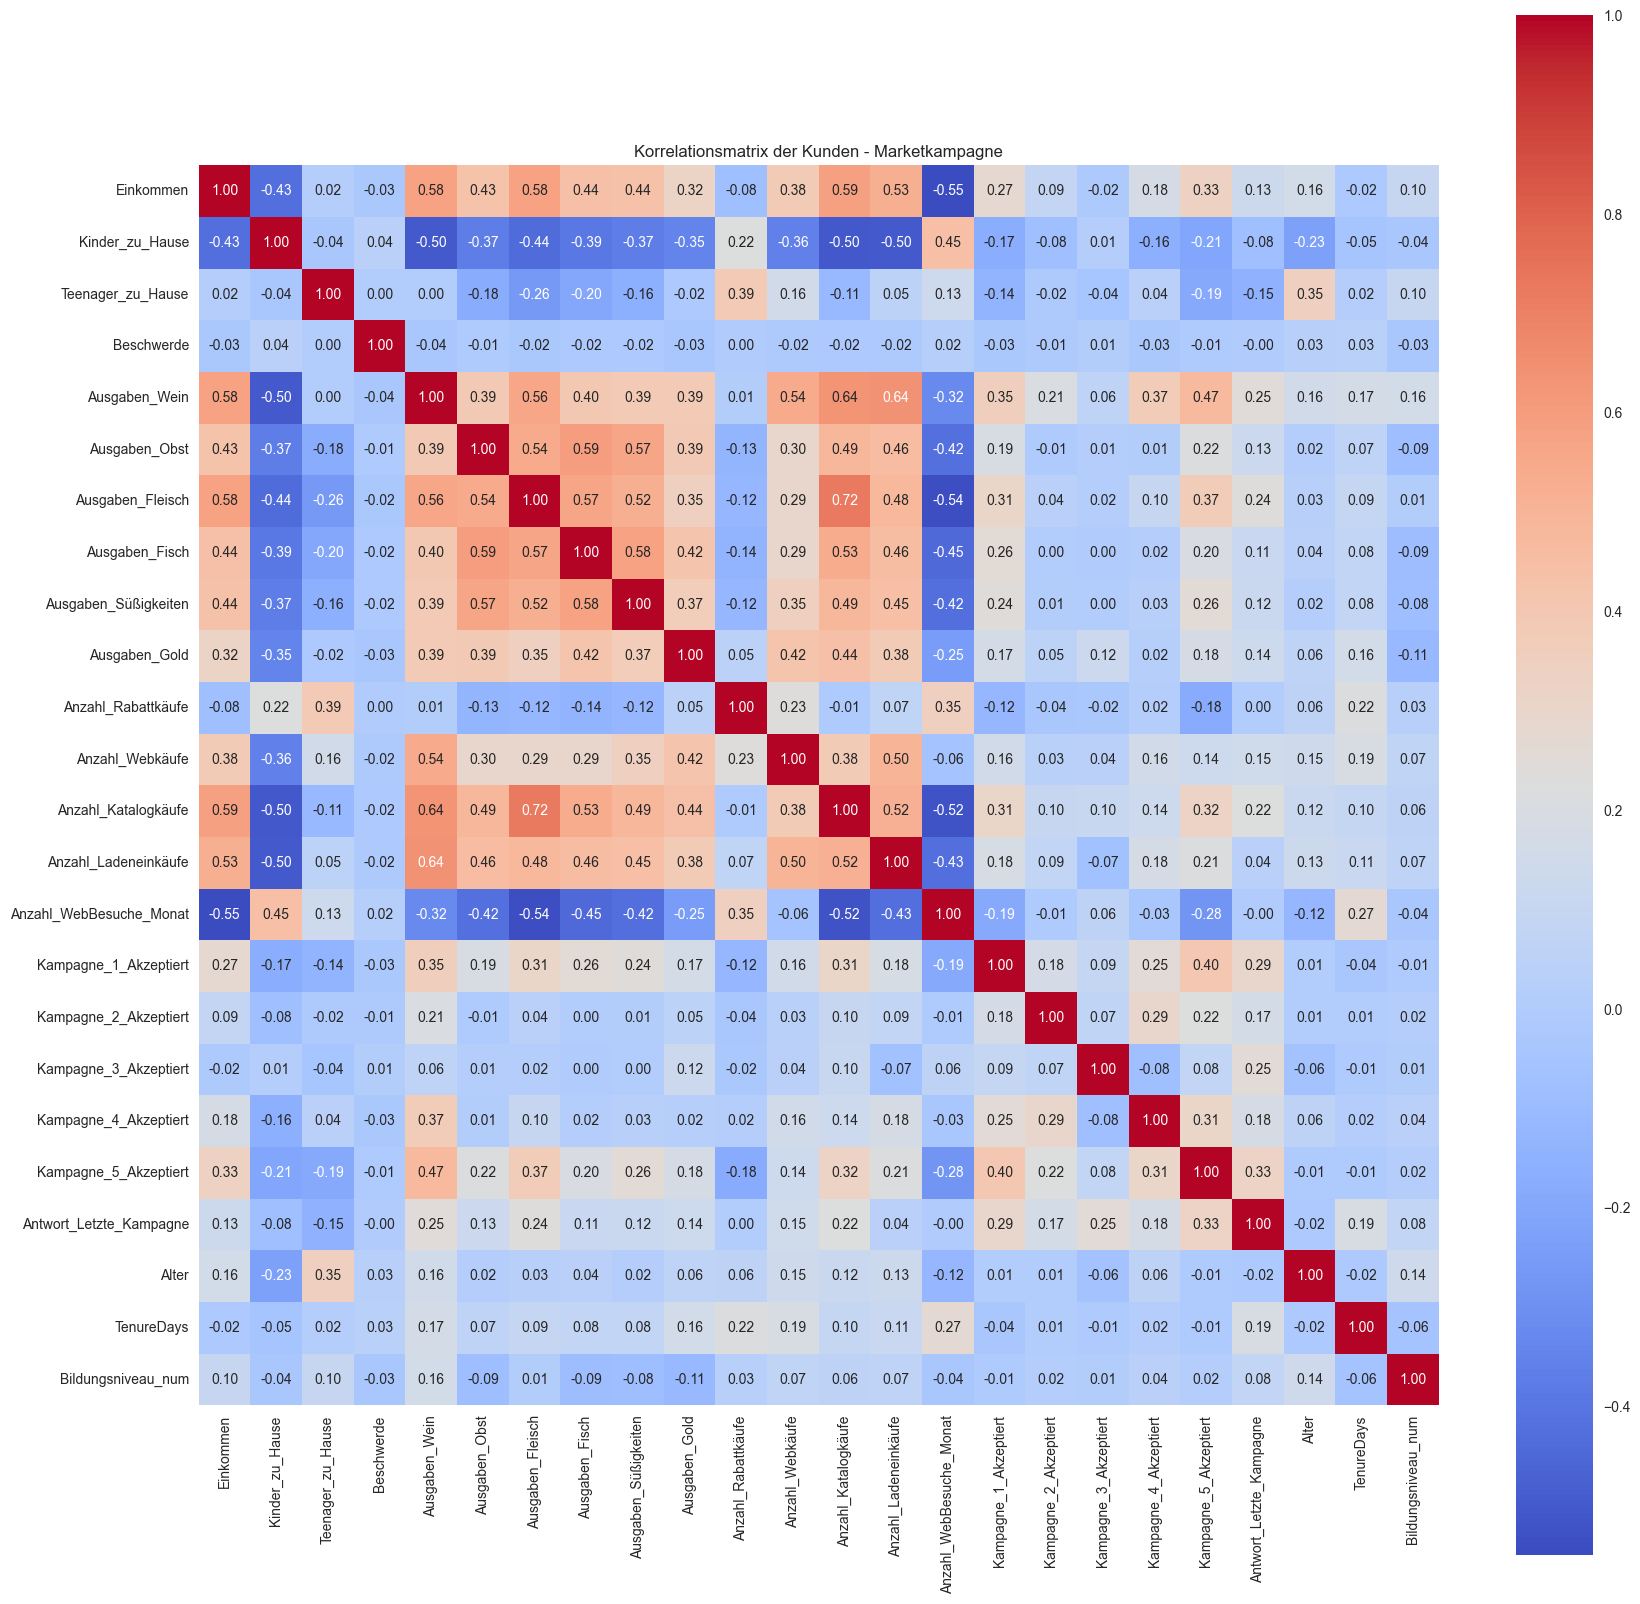

In [20]:
corr_matrix = num_df.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Korrelationsmatrix der Kunden - Marketkampagne")
plt.show()

In [21]:
df[['Kampagne_1_Akzeptiert',
    'Kampagne_2_Akzeptiert',
    'Kampagne_3_Akzeptiert',
    'Kampagne_4_Akzeptiert',
    'Kampagne_5_Akzeptiert',
    'Antwort_Letzte_Kampagne']].corr()['Antwort_Letzte_Kampagne'].sort_values(ascending=False)


Antwort_Letzte_Kampagne    1.000000
Kampagne_5_Akzeptiert      0.326634
Kampagne_1_Akzeptiert      0.293982
Kampagne_3_Akzeptiert      0.254258
Kampagne_4_Akzeptiert      0.177019
Kampagne_2_Akzeptiert      0.169293
Name: Antwort_Letzte_Kampagne, dtype: float64

In [22]:
# Obwohl fünf historische Kampagnen vorliegen, werden nur diejenigen in das Modell aufgenommen, die eine signifikante Korrelation mit der Zielvariablen zeigen. Die Kampagnen 2 und 4 werden ausgeschlossen, da sie keine erklärende Kraftfür das Antwortverhalten besitzen und lediglich Rauschen sowie Multikollinearität in das Modell einbringen

#### Logische Feature‑Gruppierung

In [23]:
# Zielvariable
target = 'Antwort_Letzte_Kampagne'

In [24]:
# Feature‑Gruppen
Kundenwert = ['Einkommen', 'TenureDays', 'Alter']
Kauf_und_Kanal = ['Anzahl_Rabattkäufe', 'Anzahl_Webkäufe', 'Anzahl_Katalogkäufe', 'Anzahl_Ladeneinkäufe', 'Anzahl_WebBesuche_Monat']
Kampagnenhistorie = ['Kampagne_1_Akzeptiert', 'Kampagne_3_Akzeptiert', 'Kampagne_5_Akzeptiert']
Demografie = ['Kinder_zu_Hause', 'Teenager_zu_Hause', 'Familienstand', 'Bildungsniveau_num']


In [25]:
# 'Ausgaben_' NICHT einzeln* (stark korreliert → Overfitting).
ausgaben_cols = [c for c in df.columns if c.startswith('Ausgaben_')]
df['Gesamtausgaben'] = df[ausgaben_cols].sum(axis=1)

df = df.drop(columns=ausgaben_cols)
df

,Familienstand,Einkommen,Kinder_zu_Hause,Teenager_zu_Hause,Letzter_Kauf_Tage,Beschwerde,Anzahl_Rabattkäufe,Anzahl_Webkäufe,Anzahl_Katalogkäufe,Anzahl_Ladeneinkäufe,...,Kampagne_1_Akzeptiert,Kampagne_2_Akzeptiert,Kampagne_3_Akzeptiert,Kampagne_4_Akzeptiert,Kampagne_5_Akzeptiert,Antwort_Letzte_Kampagne,Alter,TenureDays,Bildungsniveau_num,Gesamtausgaben
0,Ledig,58138.0,0,0,58,0,3,8,10,4,...,0,0,0,0,0,1,57,664,2,1617
1,Ledig,46344.0,1,1,38,0,2,1,1,2,...,0,0,0,0,0,0,60,113,2,27
2,Zusammenlebend,71613.0,0,0,26,0,1,8,2,10,...,0,0,0,0,0,0,49,313,2,776
3,Zusammenlebend,26646.0,1,0,26,0,2,2,0,4,...,0,0,0,0,0,0,30,140,2,53
4,Verheiratet,58293.0,1,0,94,0,5,5,3,6,...,0,0,0,0,0,0,33,162,4,422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Verheiratet,61223.0,0,1,46,0,2,9,3,4,...,0,0,0,0,0,0,47,382,2,1341
2236,Zusammenlebend,64014.0,2,1,56,0,7,8,2,5,...,1,0,0,0,0,0,68,19,4,444
2237,Geschieden,56981.0,0,0,91,0,1,2,3,13,...,0,0,0,1,0,0,33,156,2,1241
2238,Zusammenlebend,69245.0,0,1,8,0,2,6,5,10,...,0,0,0,0,0,0,58,157,3,843


In [26]:
# Finales Feature‑Set
features = [
# Kundenwert
'Einkommen', 'TenureDays', 'Alter',
# Kauf & Kanal
'Anzahl_Rabattkäufe', 'Anzahl_Webkäufe', 'Anzahl_Katalogkäufe', 'Anzahl_Ladeneinkäufe', 'Anzahl_WebBesuche_Monat',
# Kampagnenhistorie
'Kampagne_1_Akzeptiert', 'Kampagne_3_Akzeptiert', 'Kampagne_5_Akzeptiert',
# Demografie
'Kinder_zu_Hause', 'Teenager_zu_Hause', 'Familienstand', 'Bildungsniveau_num',
# Aggregat
'Gesamtausgaben'
]
features

['Einkommen',
 'TenureDays',
 'Alter',
 'Anzahl_Rabattkäufe',
 'Anzahl_Webkäufe',
 'Anzahl_Katalogkäufe',
 'Anzahl_Ladeneinkäufe',
 'Anzahl_WebBesuche_Monat',
 'Kampagne_1_Akzeptiert',
 'Kampagne_3_Akzeptiert',
 'Kampagne_5_Akzeptiert',
 'Kinder_zu_Hause',
 'Teenager_zu_Hause',
 'Familienstand',
 'Bildungsniveau_num',
 'Gesamtausgaben']

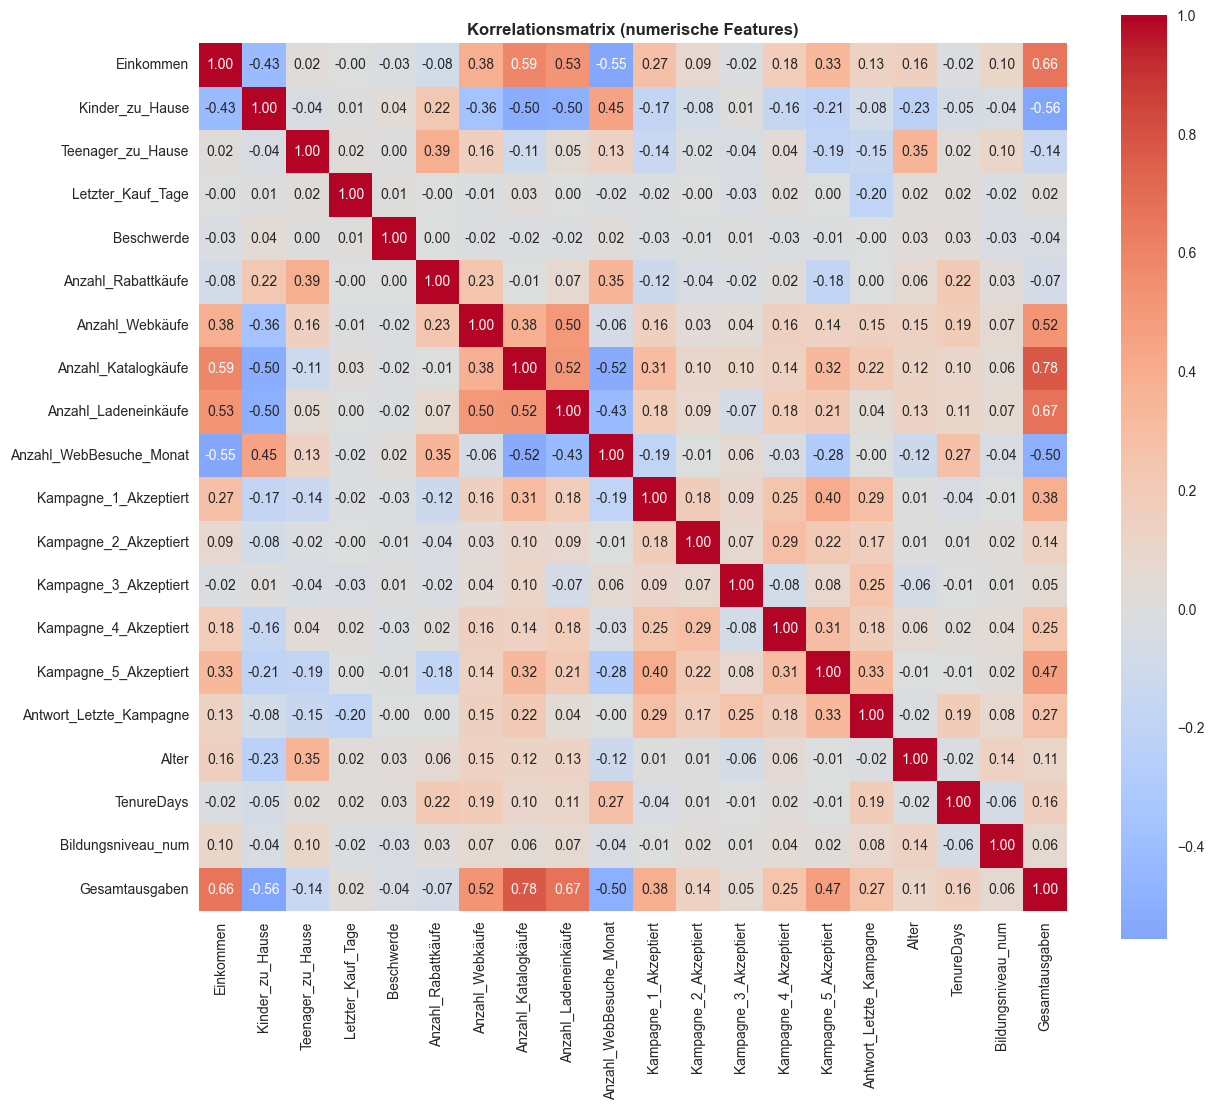

In [27]:
num_df = df.select_dtypes(include=["int64", "float64"])
corr = num_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True)
plt.title("Korrelationsmatrix (numerische Features)", fontweight="bold")
plt.show()


#### Modellierung

In [28]:
# Train‑Test‑Split
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [29]:
# Preprocessing + Logistic Regression (Pipeline)

num_features = X.select_dtypes(include=['int64','float64']).columns
cat_features = X.select_dtypes(include=['object']).columns


transformer = ColumnTransformer([
('scaling', StandardScaler(), num_features),
('onehot', OneHotEncoder(drop='first', sparse_output=False), cat_features)
])


pipeline = Pipeline([
('col_transformer', transformer),
('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])


pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('col_transformer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaling', ...), ('onehot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

Warum Logistische Regression?
 - Ziel ist binär (Antwort ja/nein)
 - Interpretierbare Koeffizienten
 - Robust bei moderater Feature‑Anzahl

#### Modellbewertung

Training Accuracy:  0.805
Training Precision: 0.418
Training Recall:    0.774
Training F1:        0.543
Training ROC-AUC:   0.872


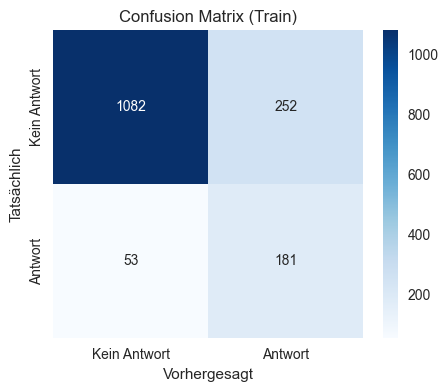

In [30]:
y_train_pred = pipeline.predict(X_train)
y_train_proba = pipeline.predict_proba(X_train)[:, 1]

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)
auc_train = roc_auc_score(y_train, y_train_proba)

print(f"Training Accuracy:  {train_accuracy:.3f}")
print(f"Training Precision: {train_precision:.3f}")
print(f"Training Recall:    {train_recall:.3f}")
print(f"Training F1:        {f1_train:.3f}")
print(f"Training ROC-AUC:   {auc_train:.3f}")

cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_train,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Kein Antwort", "Antwort"],
            yticklabels=["Kein Antwort", "Antwort"])
plt.xlabel("Vorhergesagt")
plt.ylabel("Tatsächlich")
plt.title("Confusion Matrix (Train)")
plt.show()

Testing Accuracy:  0.810
Testing Precision: 0.421
Testing Recall:    0.750
Testing F1:        0.540
Testing ROC-AUC:   0.866


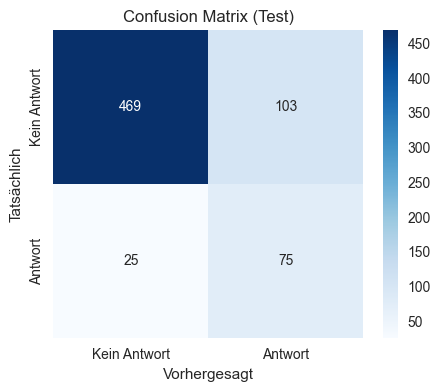

In [31]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1_test = f1_score(y_test, y_pred)
auc_test = roc_auc_score(y_test, y_proba)

print(f"Testing Accuracy:  {accuracy:.3f}")
print(f"Testing Precision: {precision:.3f}")
print(f"Testing Recall:    {recall:.3f}")
print(f"Testing F1:        {f1_test:.3f}")
print(f"Testing ROC-AUC:   {auc_test:.3f}")

cm_test = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_test,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Kein Antwort", "Antwort"],
            yticklabels=["Kein Antwort", "Antwort"])
plt.xlabel("Vorhergesagt")
plt.ylabel("Tatsächlich")
plt.title("Confusion Matrix (Test)")
plt.show()

In [32]:
model = pipeline.named_steps["model"]

ct = pipeline.named_steps["col_transformer"]
num_names = list(num_features)

ohe = ct.named_transformers_["onehot"]
cat_names = list(ohe.get_feature_names_out(cat_features))

all_feature_names = num_names + cat_names
coef = model.coef_[0]

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coef,
    "AbsCoefficient": np.abs(coef)
}).sort_values(by="AbsCoefficient", ascending=False)

print(importance_df.head(10))


                         Feature  Coefficient  AbsCoefficient
16     Familienstand_Verheiratet    -0.941523        0.941523
18  Familienstand_Zusammenlebend    -0.856116        0.856116
1                     TenureDays     0.712759        0.712759
6           Anzahl_Ladeneinkäufe    -0.700228        0.700228
12             Teenager_zu_Hause    -0.556635        0.556635
9          Kampagne_3_Akzeptiert     0.549693        0.549693
10         Kampagne_5_Akzeptiert     0.437022        0.437022
8          Kampagne_1_Akzeptiert     0.424870        0.424870
14                Gesamtausgaben     0.361374        0.361374
5            Anzahl_Katalogkäufe     0.338249        0.338249


#### 🔹 Vergleich der Modellleistung: Trainings- vs. Testdaten

| Metrik        | Training | Test  | Differenz |
| ------------- | -------- | ----- | --------- |
| **Accuracy**  | 0.805    | 0.810 | +0.005    |
| **Precision** | 0.418    | 0.421 | +0.003    |
| **Recall**    | 0.774    | 0.750 | −0.024    |
| **F1-Score**  | 0.543    | 0.540 | −0.003    |
| **ROC-AUC**   | 0.872    | 0.866 | −0.006    |


In [33]:
# --- 1) Vergleich Train vs Test (inkl. Differenz) ---

df_compare = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Training": [
        train_accuracy,
        train_precision,
        train_recall,
        f1_train,
        auc_train
    ],
    "Test": [
        accuracy,
        precision,
        recall,
        f1_test,
        auc_test
    ]
})

df_compare["Differenz (Test - Train)"] = df_compare["Test"] - df_compare["Training"]

df_compare = df_compare.round(3)

display(df_compare)



,Metrik,Training,Test,Differenz (Test - Train)
0,Accuracy,0.805,0.810,0.004
1,Precision,0.418,0.421,0.003
2,Recall,0.774,0.750,-0.024
3,F1-Score,0.543,0.540,-0.003
4,ROC-AUC,0.872,0.866,-0.006


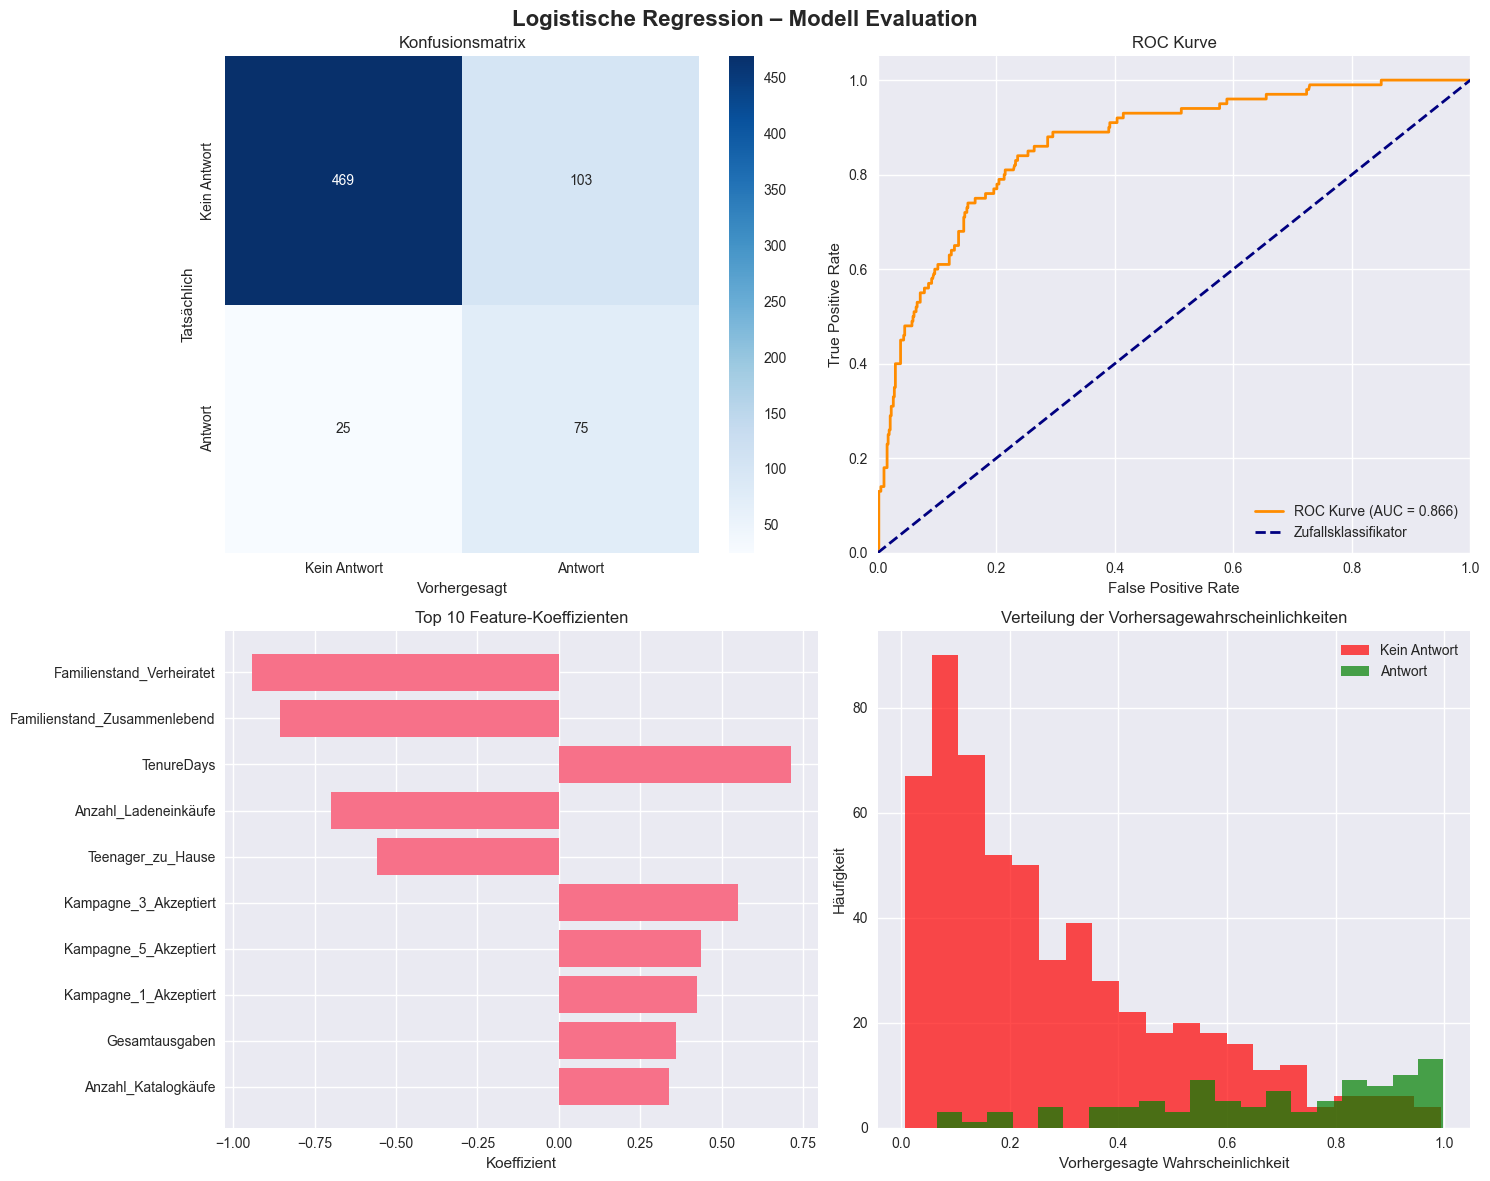

In [34]:
# === 2x2 Modell-Evaluation ===
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Logistische Regression – Modell Evaluation", fontsize=16, fontweight="bold")

# -------------------------------------------------------
# 1) Confusion Matrix
sns.heatmap(
    cm_test, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Kein Antwort", "Antwort"],
    yticklabels=["Kein Antwort", "Antwort"],
    ax=axes[0, 0]
)
axes[0, 0].set_title("Konfusionsmatrix")
axes[0, 0].set_xlabel("Vorhergesagt")
axes[0, 0].set_ylabel("Tatsächlich")

# -------------------------------------------------------
# 2) ROC Kurve
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc_value = auc(fpr, tpr)

axes[0, 1].plot(fpr, tpr, color="darkorange", lw=2,
                label=f"ROC Kurve (AUC = {roc_auc_value:.3f})")
axes[0, 1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--",
                label="Zufallsklassifikator")
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_title("ROC Kurve")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].legend(loc="lower right")

# -------------------------------------------------------
# 3) Top Feature Koeffizienten (Wichtigkeit)
top_features = importance_df.head(10)

axes[1, 0].barh(top_features["Feature"], top_features["Coefficient"])
axes[1, 0].set_title("Top 10 Feature-Koeffizienten")
axes[1, 0].set_xlabel("Koeffizient")
axes[1, 0].invert_yaxis()

# -------------------------------------------------------
# 4) Verteilung der Vorhersagewahrscheinlichkeiten
axes[1, 1].hist(y_proba[y_test == 0], bins=20, alpha=0.7,
                label="Kein Antwort", color="red")
axes[1, 1].hist(y_proba[y_test == 1], bins=20, alpha=0.7,
                label="Antwort", color="green")
axes[1, 1].set_title("Verteilung der Vorhersagewahrscheinlichkeiten")
axes[1, 1].set_xlabel("Vorhergesagte Wahrscheinlichkeit")
axes[1, 1].set_ylabel("Häufigkeit")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


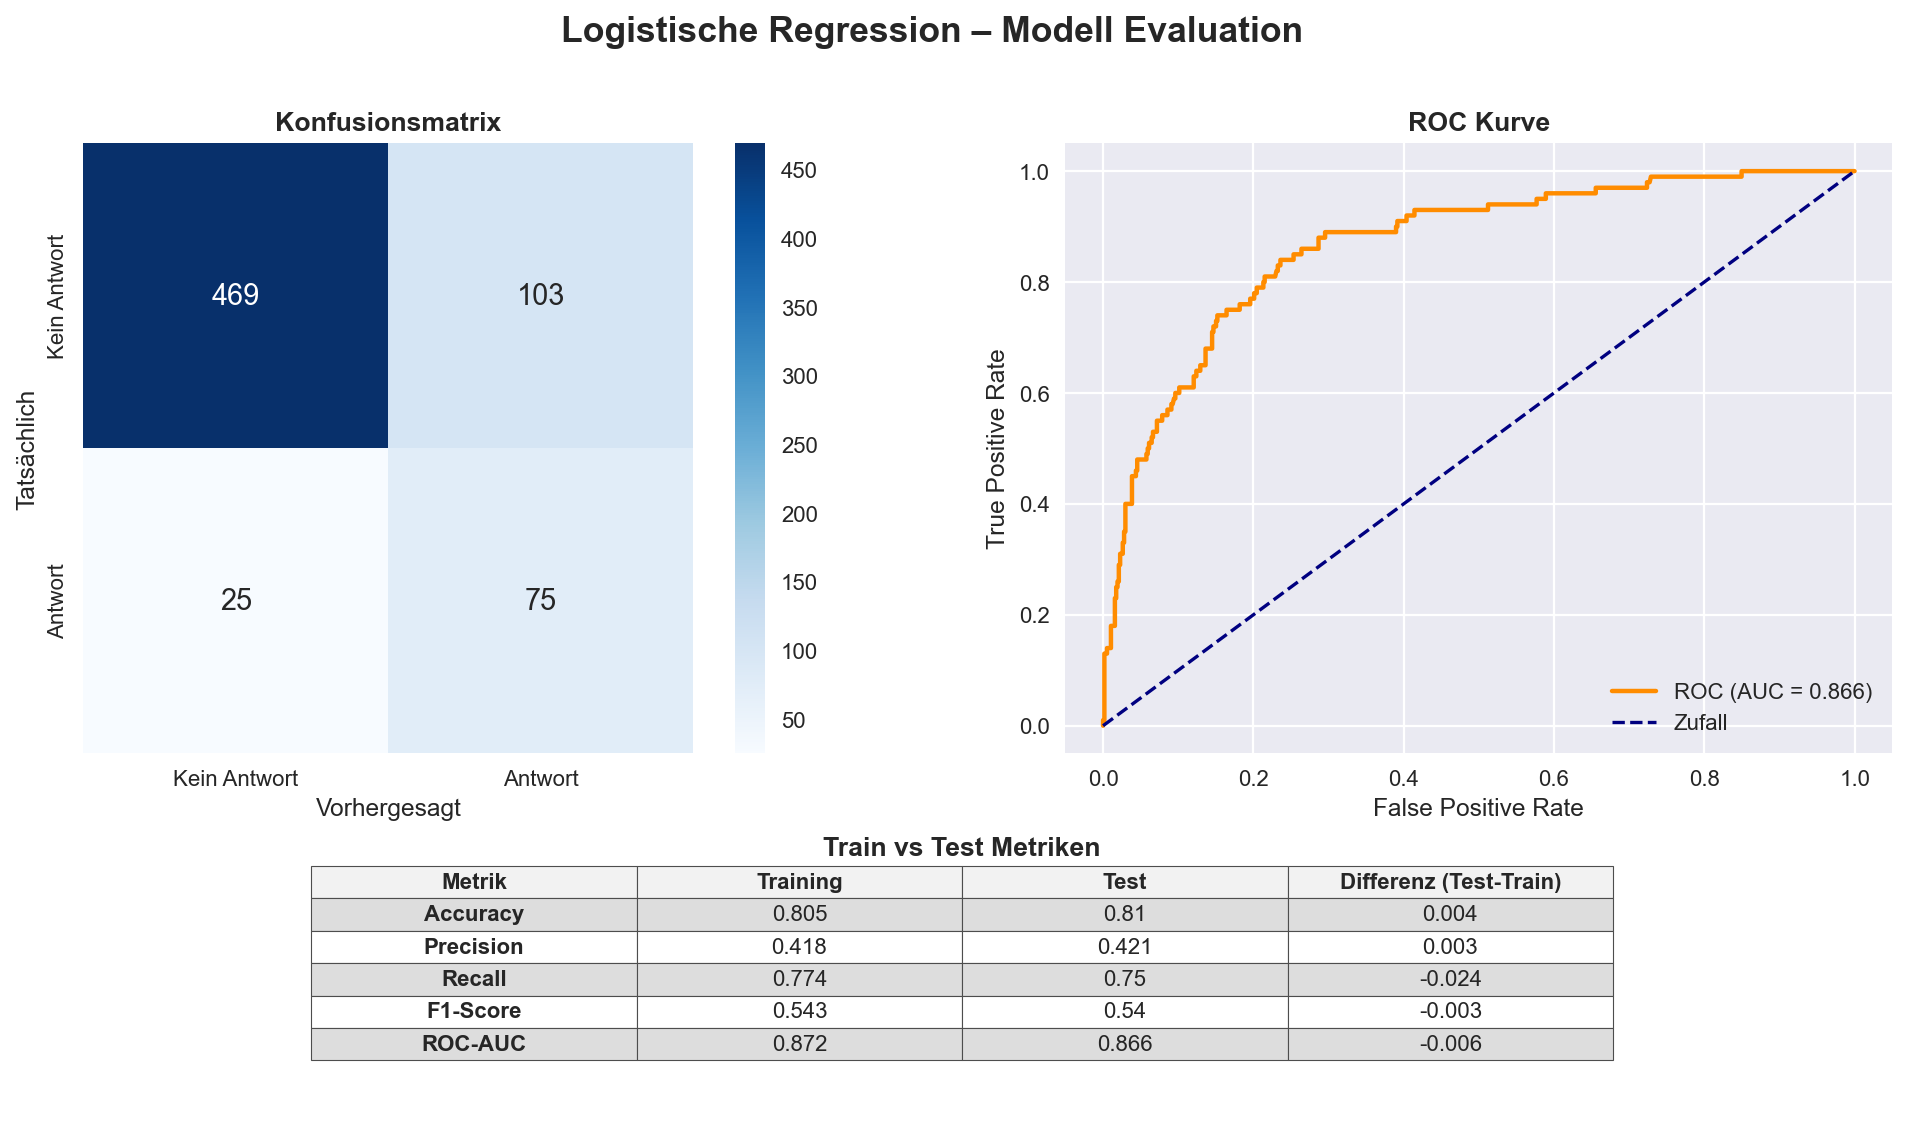

In [ ]:
from matplotlib.gridspec import GridSpec
from sklearn.metrics import roc_curve, auc

# 1) ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_value = auc(fpr, tpr)

# 2) Figure + Layout
fig = plt.figure(figsize=(15, 8), dpi=160)
gs = GridSpec(2, 2, figure=fig, height_ratios=[3.2, 1.2], hspace=0.35, wspace=0.25)

fig.suptitle("Logistische Regression – Modell Evaluation",
             fontsize=16, fontweight="bold", y=0.98)

# -------------------------------------------------------
# A) Confusion Matrix 
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    square=True,
    annot_kws={"size": 13, "weight": "regular"}, 
    xticklabels=["Kein Antwort", "Antwort"],
    yticklabels=["Kein Antwort", "Antwort"],
    ax=ax1
)
ax1.set_title("Konfusionsmatrix", fontsize=12, fontweight="bold")
ax1.set_xlabel("Vorhergesagt", fontsize=11)
ax1.set_ylabel("Tatsächlich", fontsize=11)

# -------------------------------------------------------
# B) ROC Curve 
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {roc_auc_value:.3f})")
ax2.plot([0, 1], [0, 1], linestyle="--", color="navy", lw=1.5, label="Zufall")

ax2.set_title("ROC Kurve", fontsize=12, fontweight="bold")
ax2.set_xlabel("False Positive Rate", fontsize=11)
ax2.set_ylabel("True Positive Rate", fontsize=11)
ax2.grid(alpha=1)
ax2.legend(loc="lower right", fontsize=10)

# -------------------------------------------------------
# C) Train vs Test Metriken
ax3 = fig.add_subplot(gs[1, :])
ax3.axis("off")

col_labels = ["Metrik", "Training", "Test", "Differenz (Test-Train)"]

table = ax3.table(
    cellText=df_compare.values,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    bbox=[0.15, 0.30, 0.7, 0.85]
)

for (row, col), cell in table.get_celld().items():
    cell.set_height(0.09)

    if row == 0:
        cell.set_text_props(weight="bold")
        #cell.set_height(cell.get_height() * 2.2)
        cell.set_facecolor("#f2f2f2")             
        cell.set_edgecolor("#4d4d4d")
        cell.set_linewidth(0.5)
        continue  

    if row % 2 == 1:
        cell.set_facecolor("#dddddd")
    else:
        cell.set_facecolor("white")

    cell.set_edgecolor("#4d4d4d")
    cell.set_linewidth(0.5)

    if col == 0:
        cell.set_text_props(weight="bold")

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(2.4, 3.8)

ax3.set_title("Train vs Test Metriken", fontsize=12, fontweight="bold", pad=20)

plt.show()


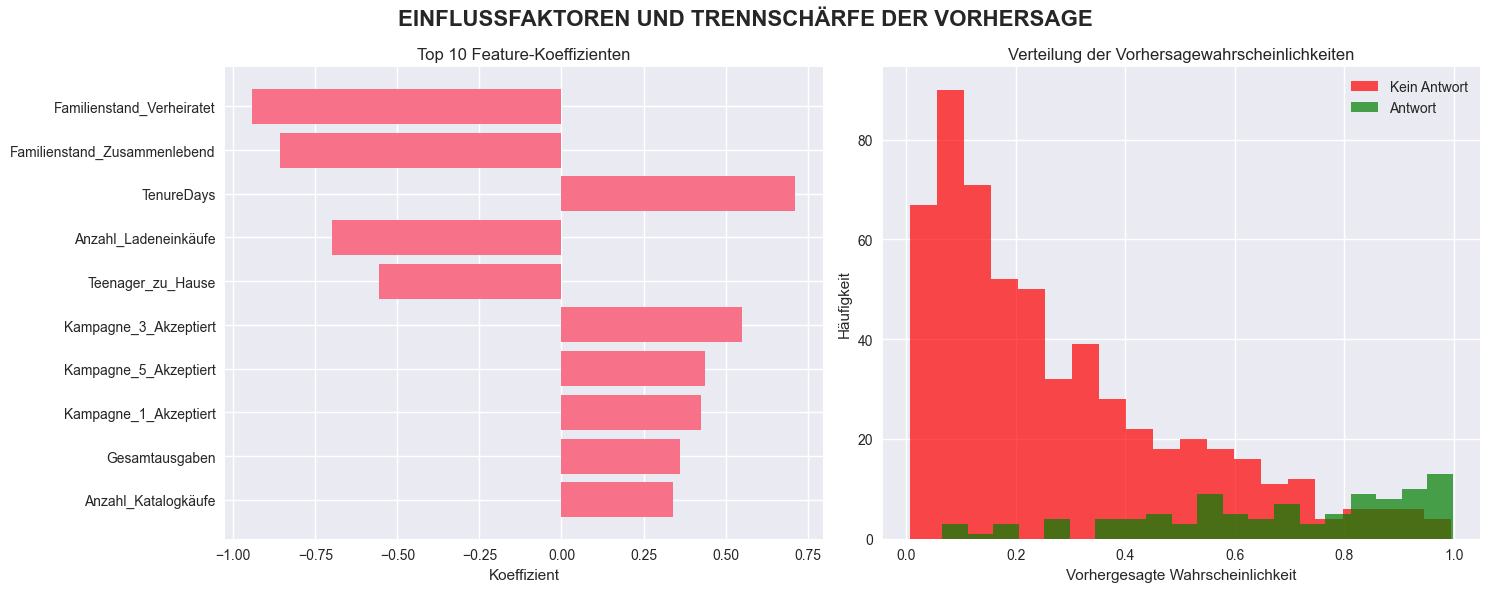

In [36]:
# === 1x2 Modell-Evaluation ===
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("EINFLUSSFAKTOREN UND TRENNSCHÄRFE DER VORHERSAGE", fontsize=16, fontweight="bold")

# -------------------------------------------------------
# 1) Top Feature Koeffizienten (Wichtigkeit)
top_features = importance_df.head(10)

axes[0].barh(top_features["Feature"], top_features["Coefficient"])
axes[0].set_title("Top 10 Feature-Koeffizienten")
axes[0].set_xlabel("Koeffizient")
axes[0].invert_yaxis()

# -------------------------------------------------------
# 2) Verteilung der Vorhersagewahrscheinlichkeiten
axes[1].hist(y_proba[y_test == 0], bins=20, alpha=0.7,
                label="Kein Antwort", color="red")
axes[1].hist(y_proba[y_test == 1], bins=20, alpha=0.7,
                label="Antwort", color="green")
axes[1].set_title("Verteilung der Vorhersagewahrscheinlichkeiten")
axes[1].set_xlabel("Vorhergesagte Wahrscheinlichkeit")
axes[1].set_ylabel("Häufigkeit")
axes[1].legend()

plt.tight_layout()
plt.show()


In [37]:
interpretation = {
    "Accuracy": "Gute Gesamtgenauigkeit.",
    "Precision": "Von allen als 'Antwort' markierten Kunden reagiert nur ein Teil wirklich (Streuverluste möglich).",
    "Recall": "Das Modell findet den Großteil aller tatsächlichen Antworter (entscheidend für Marketing!).",
    "F1-Score": "Zeigt die Balance zwischen Finden von Antwortern und Vermeidung von Fehlklassifikation.",
    "ROC-AUC": "Sehr gute Trennschärfe der Kundengruppen unabhängig vom Schwellenwert."
}

df_marketing = pd.DataFrame({
    "Metrik": df_compare["Metrik"],
    "Testwert": df_compare["Test"],
    "Marketing-Interpretation": [interpretation[m] for m in df_compare["Metrik"]]
})

display(df_marketing)


,Metrik,Testwert,Marketing-Interpretation
0,Accuracy,0.810,Gute Gesamtgenauigkeit.
1,Precision,0.421,Von allen als 'Antwort' markierten Kunden reag...
2,Recall,0.750,Das Modell findet den Großteil aller tatsächli...
3,F1-Score,0.540,Zeigt die Balance zwischen Finden von Antworte...
4,ROC-AUC,0.866,Sehr gute Trennschärfe der Kundengruppen unabh...


In [38]:
# thresholds
thresholds = [0.8, 0.6, 0.4, 0.3]

rows = []
n = len(y_proba)

for t in thresholds:
    mask = (y_proba >= t)              # Wen würden wir bei einer solchen Schwelle für die Kampagne auswählen
    selected = mask.sum()              # Wie viele Kunden wurden ausgewählt
    share = selected / n               # Anteil an allen
    
    if selected > 0:
        response_rate = y_test[mask].mean()   # tatsächlicher Anteil der Antworten unter den ausgewählten
    else:
        response_rate = np.nan

    rows.append({
        "Schwellenwert": t,
        "Anteil Kunden": round(share * 100, 1),          # in %
        "Kunden (Anzahl)": int(selected),
        "Erwartete Response-Rate": round(response_rate * 100, 1) if selected > 0 else None
    })

df_threshold_table = pd.DataFrame(rows)

df_threshold_table["Anteil Kunden"] = df_threshold_table["Anteil Kunden"].astype(str) + " %"
df_threshold_table["Erwartete Response-Rate"] = df_threshold_table["Erwartete Response-Rate"].astype(str) + " %"

df_threshold_table


,Schwellenwert,Anteil Kunden,Kunden (Anzahl),Erwartete Response-Rate
0,0.8,9.4 %,63,65.1 %
1,0.6,18.8 %,126,48.4 %
2,0.4,34.1 %,229,36.7 %
3,0.3,44.6 %,300,29.7 %


#### Clusteranalyse (K-Means)

Ziel der Clusterbildung: „Kundentypen” anhand ihres Verhaltens zu identifizieren, um:
- Mailings zu segmentieren,
- unterschiedliche Angebote zu erstellen,
- zu verstehen, wer „wertvoll” ist, wer „weggeht” und wer „Discounter” ist.

In [39]:
# 5 Merkmale:
# - 'Gesamtausgaben' – wie viel Geld der Kunde ausgegeben hat (monetär)

# - 'Gesamtkaeufe' – wie viele Einkäufe (Häufigkeit)

# - 'Letzter_Kauf_Tage' – wie viele Tage seit dem letzten Kauf (Aktualität; weniger = besser)

# - 'Anzahl_Rabattkäufe' – „Schnäppchenjäger”

# - 'Anzahl_WebBesuche_Monat' – Interesse/Aufrufe (Engagement)

In [40]:
# Kaufkanale grupieren
df["Gesamtkaeufe"] = df["Anzahl_Webkäufe"] + df["Anzahl_Katalogkäufe"] + df["Anzahl_Ladeneinkäufe"]

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Familienstand            2240 non-null   object 
 1   Einkommen                2240 non-null   float64
 2   Kinder_zu_Hause          2240 non-null   int64  
 3   Teenager_zu_Hause        2240 non-null   int64  
 4   Letzter_Kauf_Tage        2240 non-null   int64  
 5   Beschwerde               2240 non-null   int64  
 6   Anzahl_Rabattkäufe       2240 non-null   int64  
 7   Anzahl_Webkäufe          2240 non-null   int64  
 8   Anzahl_Katalogkäufe      2240 non-null   int64  
 9   Anzahl_Ladeneinkäufe     2240 non-null   int64  
 10  Anzahl_WebBesuche_Monat  2240 non-null   int64  
 11  Kampagne_1_Akzeptiert    2240 non-null   int64  
 12  Kampagne_2_Akzeptiert    2240 non-null   int64  
 13  Kampagne_3_Akzeptiert    2240 non-null   int64  
 14  Kampagne_4_Akzeptiert   

In [42]:
cluster_features = [
    "Gesamtausgaben",
    "Gesamtkaeufe",
    "Letzter_Kauf_Tage",
    "Anzahl_Rabattkäufe",
    "Anzahl_WebBesuche_Monat"
]

X_cluster = df[cluster_features].copy()

In [43]:
# Skalierung
# K-Means arbeitet mit Entfernungen. Ohne Skalierung „überlagert“ TotalSpend alle anderen Merkmale.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

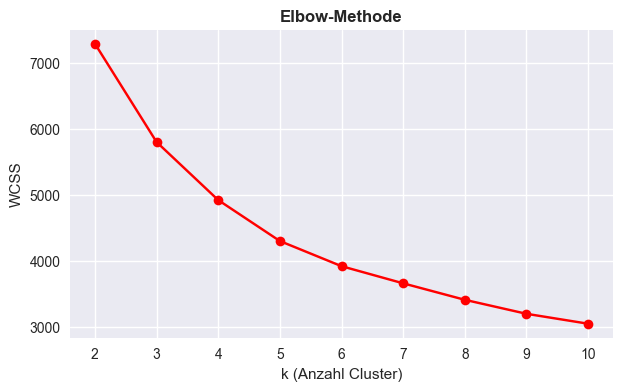

In [44]:
# Elbow
wcss = []       # WCSS = Within-Cluster Sum of Squares
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(K), wcss, marker="o", color='red')
plt.xlabel("k (Anzahl Cluster)")
plt.ylabel("WCSS")
plt.title("Elbow-Methode", fontweight="bold")
plt.grid(True)
plt.show()

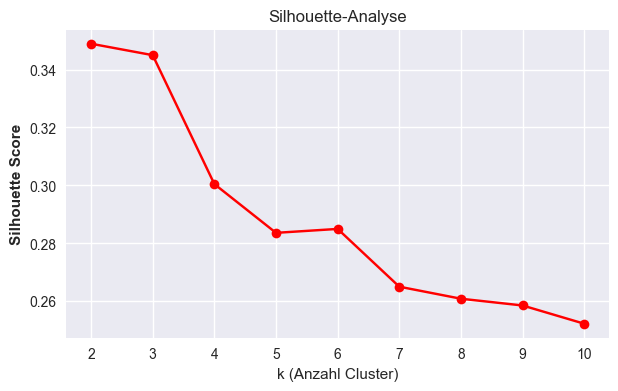

In [45]:
# Silhouette
from sklearn.metrics import silhouette_score

sil = []
K = range(2, 11)

rng = np.random.default_rng(42)
idx = rng.choice(len(X_scaled), size=min(800, len(X_scaled)), replace=False)
X_samp = X_scaled[idx]

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil.append(silhouette_score(X_samp, labels[idx]))

plt.figure(figsize=(7,4))
plt.plot(list(K), sil, marker="o", color='red')
plt.xlabel("k (Anzahl Cluster)")
plt.ylabel("Silhouette Score", fontweight="bold")
plt.title("Silhouette-Analyse")
plt.grid(True)
plt.show()


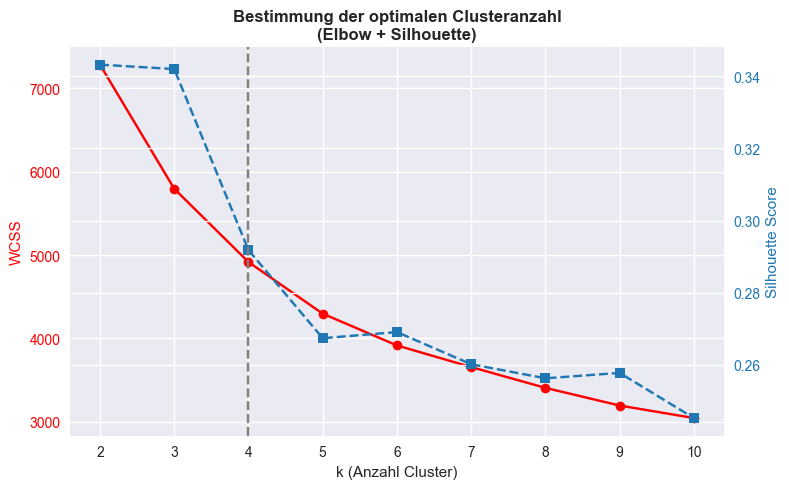

In [46]:
# Elbow + Silhouette
wcss = []
sil_scores = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, ax1 = plt.subplots(figsize=(8,5))

# --- Elbow (WCSS) - auf der ersten Achse ---
ax1.plot(list(K), wcss, marker="o", color='red', label="Elbow (WCSS)")
ax1.set_xlabel("k (Anzahl Cluster)")
ax1.set_ylabel("WCSS", color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True)

# --- Silhouette - auf der zweiten Achse ---
ax2 = ax1.twinx()
ax2.plot(list(K), sil_scores, marker="s", linestyle="--",
         color='#1f77b4', label="Silhouette Score")
ax2.set_ylabel("Silhouette Score", color='#1f77b4')
ax2.tick_params(axis='y', labelcolor='#1f77b4')

# --- Optimales k ---
plt.axvline(4, color='gray', linestyle='--')

plt.title("Bestimmung der optimalen Clusteranzahl\n(Elbow + Silhouette)", fontweight="bold")
fig.tight_layout()
plt.show()


In [47]:
# trainieren KMeans mit ausgewähltem k
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)
df.head()


,Familienstand,Einkommen,Kinder_zu_Hause,Teenager_zu_Hause,Letzter_Kauf_Tage,Beschwerde,Anzahl_Rabattkäufe,Anzahl_Webkäufe,Anzahl_Katalogkäufe,Anzahl_Ladeneinkäufe,...,Kampagne_3_Akzeptiert,Kampagne_4_Akzeptiert,Kampagne_5_Akzeptiert,Antwort_Letzte_Kampagne,Alter,TenureDays,Bildungsniveau_num,Gesamtausgaben,Gesamtkaeufe,Cluster
0,Ledig,58138.0,0,0,58,0,3,8,10,4,...,0,0,0,1,57,664,2,1617,22,2
1,Ledig,46344.0,1,1,38,0,2,1,1,2,...,0,0,0,0,60,113,2,27,4,1
2,Zusammenlebend,71613.0,0,0,26,0,1,8,2,10,...,0,0,0,0,49,313,2,776,20,2
3,Zusammenlebend,26646.0,1,0,26,0,2,2,0,4,...,0,0,0,0,30,140,2,53,6,1
4,Verheiratet,58293.0,1,0,94,0,5,5,3,6,...,0,0,0,0,33,162,4,422,14,3


cluster_colors = {0: '',  # Blue
                  1: '#ff7f0e',  # Orange
                  2: '#2ca02c',  # Green
                  3: '#d62728'}  # Red

colors = df['Cluster'].map(cluster_colors)
df['Cluster'].value_counts()

In [48]:
# Einheitliche Palette (für alle Diagramme)

from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

tab10 = plt.get_cmap("tab10")
cluster_cmap = ListedColormap(tab10.colors[:4])  # <-- streng 4 Farben

cluster_colors = {
    0: tab10.colors[0],  # blue
    1: tab10.colors[1],  # orange
    2: tab10.colors[2],  # green
    3: tab10.colors[3],  # red
}

# Legende (für alle Diagramme gleich)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=f'Cluster {k}',
           markerfacecolor=cluster_colors[k],
           markersize=8)
    for k in sorted(cluster_colors.keys())
]


#### Visualisierung von Clustern

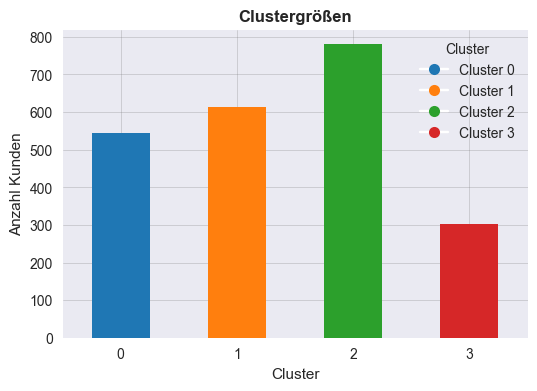

In [49]:
# Clustergröße
cluster_counts = df["Cluster"].value_counts().sort_index()

bar_colors = [cluster_colors[c] for c in cluster_counts.index]

plt.figure(figsize=(6,4))
cluster_counts.plot(kind="bar", color=bar_colors)
plt.title("Clustergrößen", fontweight="bold")
plt.xlabel("Cluster")
plt.ylabel("Anzahl Kunden")
plt.tick_params(axis="x", rotation=0)
plt.grid(True, color="gray", alpha=0.4, linestyle="-", linewidth=0.5)
plt.legend(handles=legend_elements, title="Cluster")
plt.show()


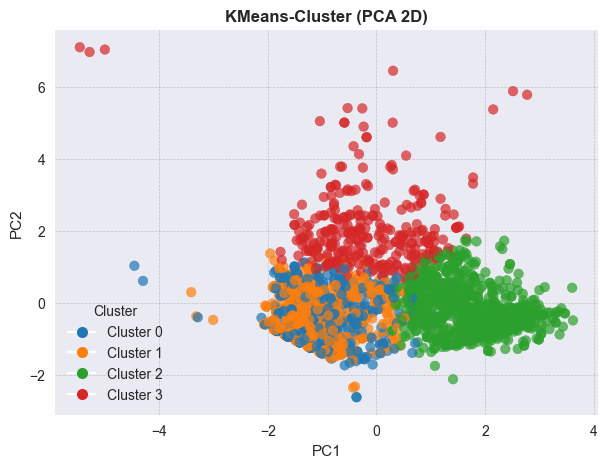

In [50]:
# 2D-Visualisierung, PCA (Principal Component Analysis)
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=df["Cluster"], cmap=cluster_cmap, alpha=0.7)

plt.title("KMeans-Cluster (PCA 2D)", fontweight="bold")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend(handles=legend_elements, title="Cluster")
plt.grid(True, color="gray", alpha=0.4, linestyle="--", linewidth=0.5)
plt.show()


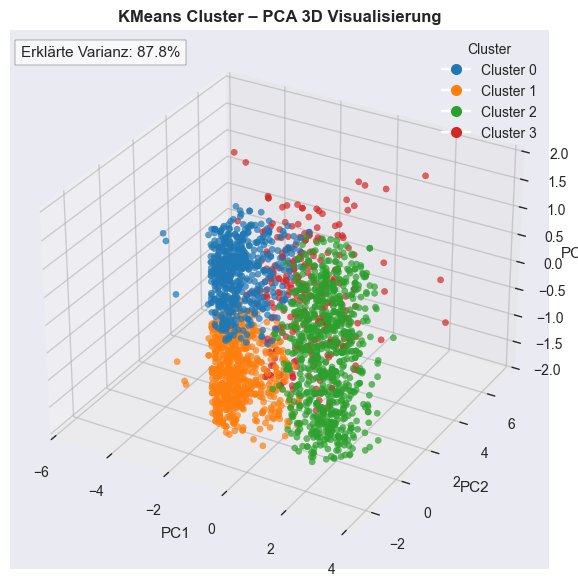

Erklärte Varianz durch PCA: 0.878


In [51]:
# 3-D Visualisierung, PCA (Principal Component Analysis)
# PCA reduziert die Vielzahl der Kundenmerkmale auf drei Hauptdimensionen, die den Großteil der Unterschiede zwischen den Kunden erklären. Dadurch können die Cluster anschaulich im 3D-Raum visualisiert werden.

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

tab10 = plt.get_cmap('tab10')
cluster_cmap = ListedColormap(tab10.colors[:4])

# PCA für 3 Komponenten
pca = PCA(n_components=3, random_state=42)
X_3d = pca.fit_transform(X_scaled)

colors = df['Cluster'].map(cluster_colors)

# 3D Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    X_3d[:, 0],
    X_3d[:, 1],
    X_3d[:, 2],
    c=df["Cluster"],
    cmap=cluster_cmap,
    alpha=0.7
)

ax.set_title("KMeans Cluster – PCA 3D Visualisierung", fontweight="bold")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.legend(handles=legend_elements, title="Cluster")

ax.xaxis._axinfo["grid"]['color'] = (0.7, 0.7, 0.7, 0.6)
ax.yaxis._axinfo["grid"]['color'] = (0.7, 0.7, 0.7, 0.6)
ax.zaxis._axinfo["grid"]['color'] = (0.7, 0.7, 0.7, 0.6)

var_explained = np.round(pca.explained_variance_ratio_.sum()*100, 1)

ax.text2D(
    0.02, 0.95,
    f"Erklärte Varianz: {var_explained}%",
    transform=ax.transAxes,
    fontsize=11,
    bbox=dict(facecolor='white', alpha=0.7)
)

plt.show()

print("Erklärte Varianz durch PCA:",
      np.round(pca.explained_variance_ratio_.sum(), 3))


### Beschreibung und Interpretation der Segmente (Clusterprofil)

In [52]:
# Tabelle „Cluster-Porträt“ nach Schlüsselmerkmalen
profile = df.groupby("Cluster")[cluster_features].mean().round(2)
profile


,Gesamtausgaben,Gesamtkaeufe,Letzter_Kauf_Tage,Anzahl_Rabattkäufe,Anzahl_WebBesuche_Monat
Cluster,,,,,
0,144.55,6.86,76.44,1.94,6.22
1,143.37,6.77,24.47,1.95,6.37
2,1257.11,19.57,49.43,1.47,3.23
3,694.62,16.32,48.97,6.00,6.93


In [53]:
# Zusätzliche Analyse: Was passiert mit Nicht-Cluster-Merkmalen innerhalb von Clustern?
extra_cols = ["Einkommen", "Alter", "TenureDays", "Antwort_Letzte_Kampagne"]
profile_extra = df.groupby("Cluster")[extra_cols].mean().round(2)
profile_extra


,Einkommen,Alter,TenureDays,Antwort_Letzte_Kampagne
Cluster,,,,
0,37845.99,44.07,323.82,0.04
1,38415.76,43.02,325.50,0.14
2,72858.35,46.80,354.44,0.23
3,53008.69,47.48,468.22,0.18


#### RFM + Response Prinzip
| Wenn im Cluster …                                          | Bedeutung (Interpretation)                          |
| ---------------------------------------------------------- | --------------------------------------------------- |
| **hohe Gesamtausgaben** + **hohe Gesamtkaeufe**            | wertvolle, loyale Stammkunden                       |
| **hoher Letzter_Kauf_Tage** (lange Zeit seit letztem Kauf) | „schlafende“ / inaktive Kunden                      |
| **hohe Antwort_Letzte_Kampagne**                           | marketing-sensitive Kunden, reagieren auf Kampagnen |
| **niedrige Gesamtausgaben**, aber **hohe Gesamtkaeufe**    | günstige, aber sehr aktive Käufer                   |

Die Cluster werden anhand zentraler Verhaltensmerkmale interpretiert: Gesamtausgaben (Monetary), Gesamtkaeufe (Frequency), Letzter_Kauf_Tage (Recency) sowie Antwort_Letzte_Kampagne als Indikator für Marketingreaktion. Dadurch erhalten die Segmente eine klare geschäftliche Bedeutung.

| Cluster | M (Gesamtausgaben) | F (Gesamtkaeufe) | R (Letzter_Kauf_Tage) | Response     |
| ------- | ------------------ | ---------------- | --------------------- | ------------ |
| 0       | mittel             | niedrig          | hoch                  | sehr niedrig |
| 1       | mittel             | niedrig          | sehr niedrig          | mittel       |
| 2       | sehr hoch          | sehr hoch        | mittel                | hoch         |
| 3       | niedrig            | hoch             | mittel                | mittel       |


In [54]:
# Cluster umbenennen

cluster_names = {
    0: "0  -->  Inaktive Kunden",
    1: "1  -->  Aktive Gelegenheitskäufer",
    2: "2  -->  Premium-Stammkunden",
    3: "3  -->  Preisorientierte Vielkäufer"
}
df["Cluster_ID"] = df["Cluster"]

df["Cluster_Name"] = df["Cluster_ID"].map(cluster_names)
df["Cluster_Name"].value_counts()

# Die Benennung der Cluster erfolgte erst nach der statistischen Profilierung der Kundengruppen

Cluster_Name
2  -->  Premium-Stammkunden            780
1  -->  Aktive Gelegenheitskäufer      613
0  -->  Inaktive Kunden                545
3  -->  Preisorientierte Vielkäufer    302
Name: count, dtype: int64

In [55]:
print(df["Cluster"].head(10))
print(sorted(df["Cluster"].astype(str).unique())[:30])
print(df["Cluster"].isna().sum())


0    2
1    1
2    2
3    1
4    3
5    2
6    3
7    1
8    1
9    0
Name: Cluster, dtype: int32
['0', '1', '2', '3']
0


In [56]:

df["Cluster_str"] = (
    df["Cluster"]
    .astype(str)
    .str.strip()      
    .str.replace(".0", "", regex=False)  # '1.0' -> '1'
)
valid_clusters = {"0", "1", "2", "3"}
df = df[df["Cluster_str"].isin(valid_clusters)].copy()

# 3) Palette mit STRING-Schlüsseln
cluster_colors_str = {
    "0": "#1f77b4",
    "1": "#ff7f0e",
    "2": "#2ca02c",
    "3": "#d62728"
}


C:\Users\NataliiaMelnytska\AppData\Local\Temp\ipykernel_41668\1928434117.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\NataliiaMelnytska\AppData\Local\Temp\ipykernel_41668\1928434117.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\NataliiaMelnytska\AppData\Local\Temp\ipykernel_41668\1928434117.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


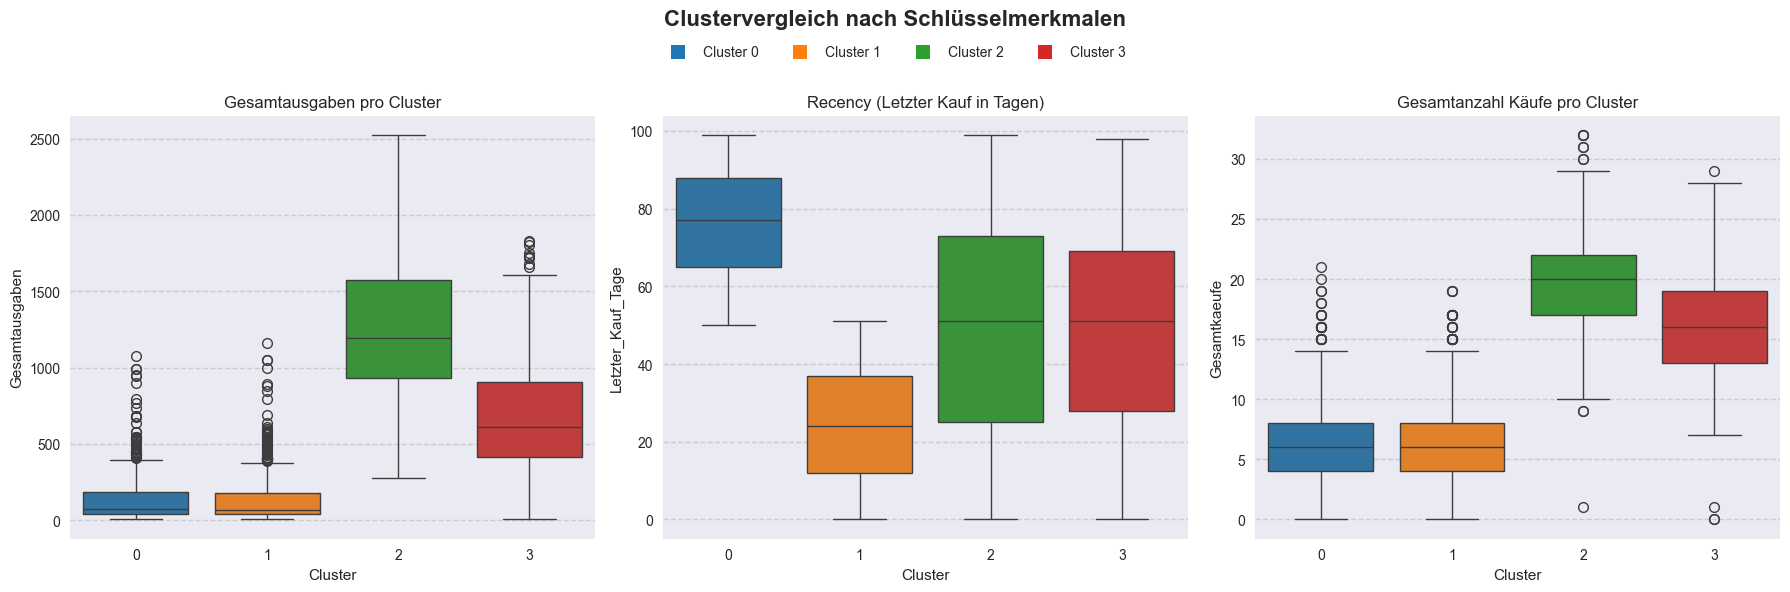

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Clustervergleich nach Schlüsselmerkmalen", fontsize=16, fontweight="bold")

order = ["0", "1", "2", "3"]

# --- 1 Umsatz ---
sns.boxplot(
    data=df,
    x="Cluster",
    y="Gesamtausgaben",
    palette=cluster_colors_str,
    ax=axes[0]
)
axes[0].set_title("Gesamtausgaben pro Cluster")
axes[0].grid(axis="y", linestyle="--", alpha=0.3, color="gray")

# --- 2 Recency ---
sns.boxplot(
    data=df,
    x="Cluster",
    y="Letzter_Kauf_Tage",
    palette=cluster_colors_str,
    ax=axes[1]
)
axes[1].set_title("Recency (Letzter Kauf in Tagen)")
axes[1].grid(axis="y", linestyle="--", alpha=0.3, color="gray")

# --- 3 Frequency ---
sns.boxplot(
    data=df,
    x="Cluster",
    y="Gesamtkaeufe",
    palette=cluster_colors_str,
    ax=axes[2]
)
axes[2].set_title("Gesamtanzahl Käufe pro Cluster")
axes[2].grid(axis="y", linestyle="--", alpha=0.3, color="gray")

# --- einheitliche Legende ---
legend_elements = [
    Line2D([0], [0], marker='s', color='w',
           label=f'Cluster {k}',
           markerfacecolor=cluster_colors_str[k],
           markersize=10)
    for k in ["0", "1", "2", "3"]
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.94)
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


#### Cluster Interpretation Phase

In [58]:
#Für die Clusteranalyse wurde K-Means auf skalierten Verhaltensmerkmalen (Gesamtausgaben, Gesamtkaeufe, Recency, Rabattkäufe, Webbesuche) angewendet. Die Wahl der Clusteranzahl erfolgte anhand der Elbow-Methode und einer Silhouette-Analyse. Anschließend wurden die Cluster anhand der Mittelwerte und Verteilungen der Merkmale interpretiert und zu aussagekräftigen Kundensegmenten zusammengefasst. Die Segmente ermöglichen eine zielgerichtete Marketingstrategie, z.B. VIP-Angebote für kaufstarke Kunden, Win-Back-Kampagnen für abwanderungsgefährdete Kunden und Rabattaktionen für preissensitive Käufer.

In [59]:
# Die Abbildung zeigt die Profile der mittels K-Means gefundenen Kundensegmente. Die Heatmap verdeutlicht klare Unterschiede in Umsatz, Kaufhäufigkeit und Recency. Zusätzlich zeigt die Antwort-Rate, dass bestimmte Segmente signifikant häufiger auf Kampagnen reagieren. Dadurch können Maßnahmen segment-spezifisch geplant werden (z.B. VIP-Angebote für Premium-Kunden, Win-Back für inaktive Kunden, Rabattaktionen für preissensitive Käufer).

In [60]:
# Segment → Maßnahme → Kanal → Angebot

marketing_plan = pd.DataFrame({
    "Segment": [
        "0  -->  Inaktive Kunden",
        "1  -->  Aktive Gelegenheitskäufer",
        "2  -->  Premium-Stammkunden",
        "3  -->  Preisorientierte Vielkäufer"
    ],
    
    "Kundenprofil": [
        "Kaufen selten, lange Zeit seit letztem Kauf, geringe Aktivität",
        "Kaufen gelegentlich, mittlere Aktivität, wenig Bindung",
        "Sehr hohe Ausgaben, häufige Käufe, sehr loyal",
        "Viele Käufe mit Rabatt, sehr preissensitiv, häufig online"
    ],
    
    "Marketingziel": [
        "Reaktivierung (Win-Back)",
        "Aktivierung und Bindung erhöhen",
        "Loyalität stärken und Premium-Angebote",
        "Gezielte Rabattaktionen steuern"
    ],
    
    "Empfohlener Kanal": [
        "E-Mail + Gutschein",
        "Personalisierte E-Mail / App Push",
        "Exklusive Angebote / Newsletter / VIP",
        "Rabatt-Mailings / Online Banner"
    ],
    
    "Konkretes Angebot": [
        "10–15% Gutschein für Rückkehr",
        "Produktempfehlungen + kleiner Rabatt",
        "VIP-Angebote ohne Rabatt, neue Produkte",
        "Zeitlich begrenzte Rabattaktionen"
    ]
})

marketing_plan


,Segment,Kundenprofil,Marketingziel,Empfohlener Kanal,Konkretes Angebot
0,0 --> Inaktive Kunden,"Kaufen selten, lange Zeit seit letztem Kauf, g...",Reaktivierung (Win-Back),E-Mail + Gutschein,10–15% Gutschein für Rückkehr
1,1 --> Aktive Gelegenheitskäufer,"Kaufen gelegentlich, mittlere Aktivität, wenig...",Aktivierung und Bindung erhöhen,Personalisierte E-Mail / App Push,Produktempfehlungen + kleiner Rabatt
2,2 --> Premium-Stammkunden,"Sehr hohe Ausgaben, häufige Käufe, sehr loyal",Loyalität stärken und Premium-Angebote,Exklusive Angebote / Newsletter / VIP,"VIP-Angebote ohne Rabatt, neue Produkte"
3,3 --> Preisorientierte Vielkäufer,"Viele Käufe mit Rabatt, sehr preissensitiv, hä...",Gezielte Rabattaktionen steuern,Rabatt-Mailings / Online Banner,Zeitlich begrenzte Rabattaktionen


#### Basierend auf der Clusteranalyse wurden vier klar unterscheidbare Kundensegmente identifiziert. Für jedes Segment wurden konkrete Marketingmaßnahmen, passende Kommunikationskanäle sowie Angebotsstrategien abgeleitet. Dadurch kann die nächste Kampagne gezielt und segment-spezifisch ausgesteuert werden, was die Effizienz deutlich erhöht.

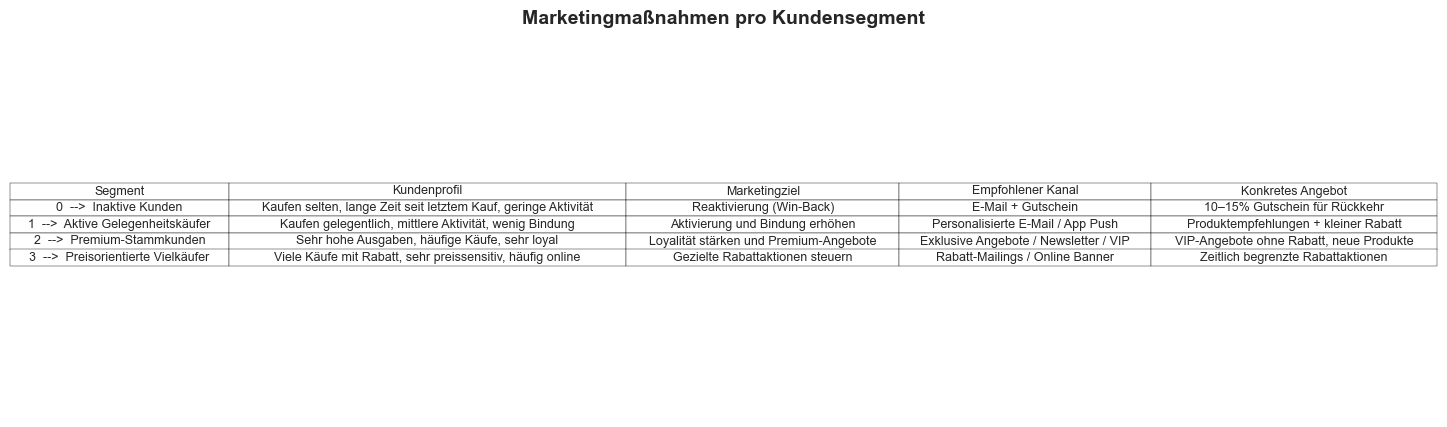

In [61]:
plt.figure(figsize=(12,5))
plt.axis('off')

table = plt.table(
    cellText=marketing_plan.values,
    colLabels=marketing_plan.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.auto_set_column_width(col=list(range(len(marketing_plan.columns))))

plt.title("Marketingmaßnahmen pro Kundensegment", fontsize=14, fontweight='bold')
plt.show()


#### Die Clusteranalyse liefert nicht nur statistische Gruppen, sondern konkrete, umsetzbare Kundensegmente. Jedes Segment zeigt ein klar unterschiedliches Kauf- und Reaktionsverhalten, wodurch Marketingmaßnahmen zielgerichtet geplant werden können. Dies ermöglicht eine deutliche Steigerung der Kampagneneffizienz bei gleichzeitiger Reduktion unnötiger Streuverluste.